In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Generate synthetic data (a Sine Wave)
t = np.arange(0, 1000)
data = np.sin(0.1 * t) + np.random.normal(scale=0.1, size=1000) # Sine + Noise

# 2. Function to create sequential input-output pairs
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 50
X, y = create_sequences(data, window_size)

# 3. Split into Train and Test sets (80/20 split)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# RNN expects input shape: (batch_size, time_steps, features)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [2]:
model = models.Sequential([
    # RNN layer to process the window of 50 steps
    layers.SimpleRNN(64, activation='relu', input_shape=(window_size, 1)),

    # Dense layer for the final prediction
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 64)                4224      
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 6,337
Trainable params: 6,337
Non-trainable params: 0
_________________________________________________________________


In [3]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=1)

Epoch 1/20
24/24 [==============================] - 1s 11ms/step - loss: 0.1620 - mae: 0.3160 - val_loss: 0.0256 - val_mae: 0.1260
Epoch 2/20
24/24 [==============================] - 0s 4ms/step - loss: 0.0234 - mae: 0.1218 - val_loss: 0.0184 - val_mae: 0.1093
Epoch 3/20
24/24 [==============================] - 0s 4ms/step - loss: 0.0183 - mae: 0.1094 - val_loss: 0.0172 - val_mae: 0.1034
Epoch 4/20
24/24 [==============================] - 0s 5ms/step - loss: 0.0166 - mae: 0.1046 - val_loss: 0.0161 - val_mae: 0.1008
Epoch 5/20
24/24 [==============================] - 0s 4ms/step - loss: 0.0167 - mae: 0.1051 - val_loss: 0.0175 - val_mae: 0.1034
Epoch 6/20
24/24 [==============================] - 0s 5ms/step - loss: 0.0167 - mae: 0.1043 - val_loss: 0.0157 - val_mae: 0.0991
Epoch 7/20
24/24 [==============================] - 0s 5ms/step - loss: 0.0161 - mae: 0.1030 - val_loss: 0.0159 - val_mae: 0.1011
Epoch 8/20
24/24 [==============================] - 0s 5ms/step - loss: 0.0156 - mae: 0.1


Mean Squared Error on Test Set: 0.01511
6/6 [==============================] - 0s 2ms/step


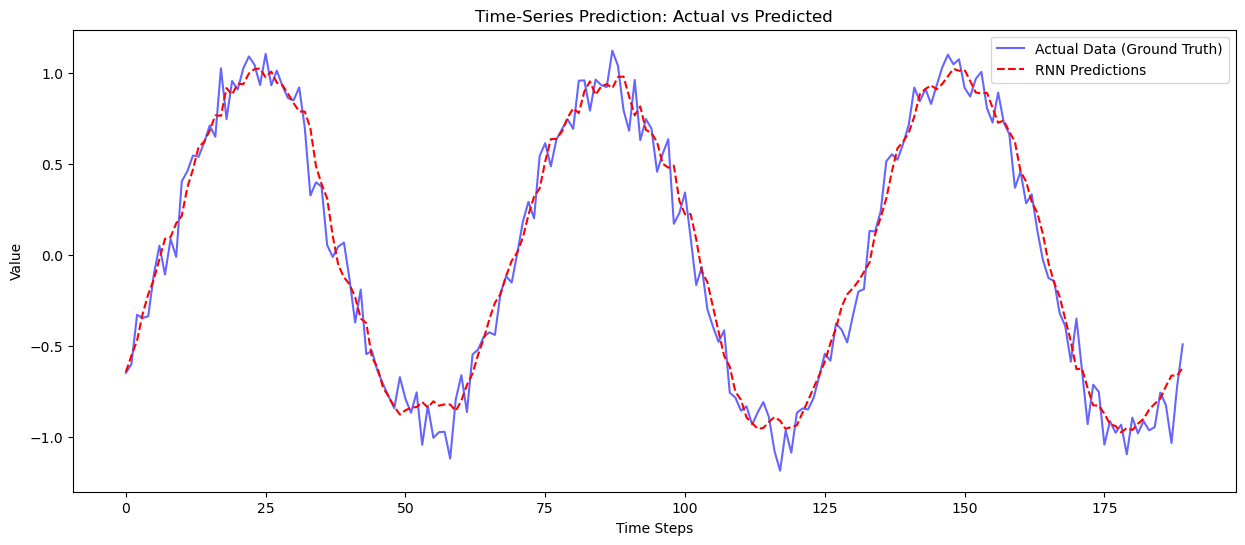

In [4]:
# 1. Evaluate Prediction Performance
mse = model.evaluate(X_test, y_test, verbose=0)[0]
print(f"\nMean Squared Error on Test Set: {mse:.5f}")

# 2. Make Predictions
predictions = model.predict(X_test)

# 3. Plot Actual vs Predicted
plt.figure(figsize=(15, 6))
plt.plot(y_test, label='Actual Data (Ground Truth)', color='blue', alpha=0.6)
plt.plot(predictions, label='RNN Predictions', color='red', linestyle='--')
plt.title('Time-Series Prediction: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()